## Import and device setup

In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True

using device: cuda


In [2]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

## Raw Image

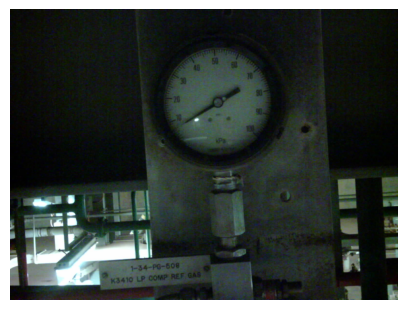

In [3]:
# Core
from pathlib import Path
# --- Config ---
base = "/mnt/projects-np/gauge-reading-poc/"

img_path = Path(f'{base}2025/10/08/08_F9_E0_90_82_40-21-02-20.jpeg')

image = Image.open(img_path)
image = np.array(image.convert("RGB"))
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.show()


## Segment the dial

In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

# Make a dynamic min-area based on image size so we only keep big regions
H, W = image.shape[:2]
img_area = H * W
min_area_coarse = int(max(0.1 * img_area, 1500))

mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=10,
    points_per_batch=8,
    pred_iou_thresh=0.82,
    stability_score_thresh=0.94,
    stability_score_offset=0.70,
    box_nms_thresh=0.50,
    min_mask_region_area=min_area_coarse,
    use_m2m=True,
)

In [5]:
masks2 = mask_generator_2.generate(image)
len(masks2)

/home/wde.woodside.com.au/w94399/github_projects/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/home/wde.woodside.com.au/w94399/github_projects/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


14

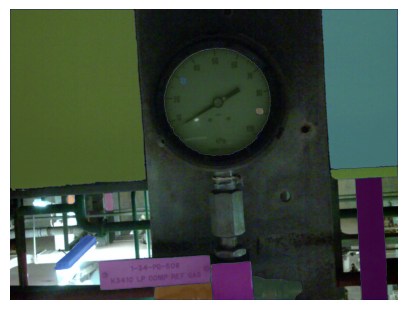

In [6]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show()

## Get SAM-derived circle prior

SAM-derived circle prior: centre=(852.6, 383.4), r=223.7


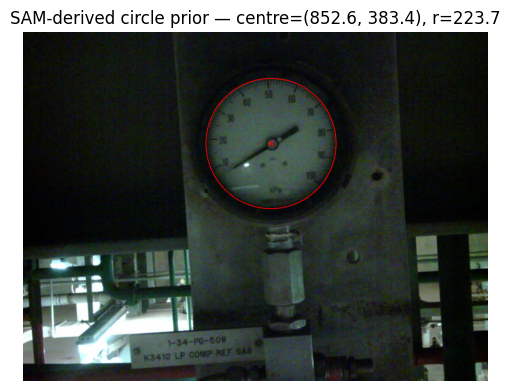

In [12]:
import cv2, numpy as np, matplotlib.pyplot as plt

H, W = image.shape[:2]
img_area = H * W

# Heuristics for circular candidates from SAM
rel_area_min, rel_area_max = 0.03, 0.60
circ_min = 0.62
border_margin = max(6, int(0.01 * min(H, W)))

# Collect contour points from the most circular, mid-sized SAM masks
cand_info = []
all_pts = []
for i, m in enumerate(masks2):
    seg = (m['segmentation'].astype(np.uint8) * 255)
    cnts, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: 
        continue
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    per  = cv2.arcLength(cnt, True) + 1e-6
    circ = (4*np.pi*area)/(per*per)

    x,y,w,h = cv2.boundingRect(cnt)
    touches_border = (x <= border_margin or y <= border_margin or
                      x+w >= W-border_margin or y+h >= H-border_margin)
    rel_area = area / (img_area + 1e-6)

    if touches_border: 
        continue
    if not (rel_area_min <= rel_area <= rel_area_max): 
        continue
    if circ < circ_min: 
        continue

    cand_info.append((circ, rel_area, i))
    all_pts.append(cnt.reshape(-1,2))

# If nothing passed, relax thresholds a bit
if len(all_pts) == 0:
    circ_min = 0.55
    for i, m in enumerate(masks2):
        seg = (m['segmentation'].astype(np.uint8) * 255)
        cnts, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts: 
            continue
        cnt = max(cnts, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        per  = cv2.arcLength(cnt, True) + 1e-6
        circ = (4*np.pi*area)/(per*per)
        if circ >= circ_min:
            all_pts.append(cnt.reshape(-1,2))

# Estimate a circle from these points (use enclosing circle as a robust, simple fit)
assert len(all_pts) > 0, "No circular cues in SAM masks; try lowering circ_min or broadening rel_area bounds."
pts = np.vstack(all_pts).astype(np.float32)
(cx_prior, cy_prior), r_prior = cv2.minEnclosingCircle(pts)
cx_prior, cy_prior, r_prior = float(cx_prior), float(cy_prior), float(r_prior)

print(f"SAM-derived circle prior: centre={round(cx_prior,1), round(cy_prior,1)}, r={round(r_prior,1)}")

# Visual sanity check (draw circle + centre marker)
overlay = image.copy()
center = (int(round(cx_prior)), int(round(cy_prior)))
radius = int(round(r_prior))

# outer circle
cv2.circle(overlay, center, radius, (255,0,0), 2)

# centre marker (cross) + optional coords label
cv2.drawMarker(overlay, center, (255,0,0),
               markerType=cv2.MARKER_TILTED_CROSS, markerSize=16, thickness=2)
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis('off')
plt.title(f"SAM-derived circle prior — centre=({cx_prior:.1f}, {cy_prior:.1f}), r={r_prior:.1f}")
plt.show()


## Crop to dial face

Crop-space centre = (235.6, 235.4)


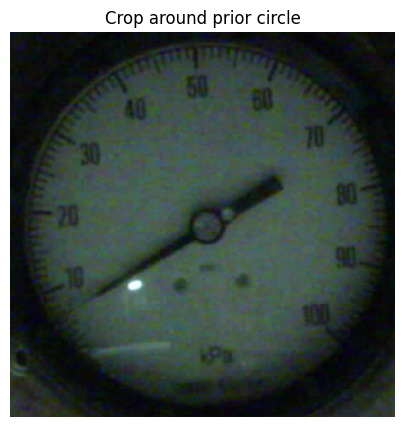

In [20]:
marg = int(0.05 * r_prior)  # 5% radius margin
x0 = max(0, int(cx_prior - r_prior - marg))
y0 = max(0, int(cy_prior - r_prior - marg))
x1 = min(W, int(cx_prior + r_prior + marg))
y1 = min(H, int(cy_prior + r_prior + marg))


# Transform circle centre to crop coordinate space
cx_crop = cx_prior - x0
cy_crop = cy_prior - y0

print(f"Crop-space centre = ({cx_crop:.1f}, {cy_crop:.1f})")



crop = image[y0:y1, x0:x1]

plt.figure(figsize=(5,5))
plt.imshow(crop); plt.axis('off'); plt.title("Crop around prior circle")
plt.show()



## Segment within the dial for text and needle

In [14]:
mask_generator_inside = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=20,           # 48–64 keeps granularity down
    points_per_batch=16,
    pred_iou_thresh=0.80,         # be stricter
    stability_score_thresh=0.92,  # be stricter
    stability_score_offset=0.70,
    crop_n_layers=1,              # fewer scales → fewer tiny fragments
    crop_n_points_downscale_factor=2,
    box_nms_thresh=0.55,
    min_mask_region_area=600,     # absolute floor; we’ll also apply a face-relative floor next
    use_m2m=True,
)

masks_inside = mask_generator_inside.generate(crop)
print("Inside masks:", len(masks_inside))


Inside masks: 17


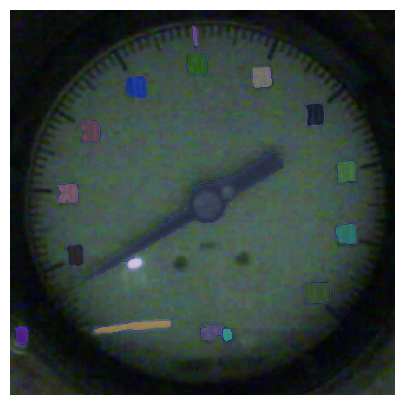

In [15]:
plt.figure(figsize=(5, 5))
plt.imshow(crop)
show_anns(masks_inside)
plt.axis('off')
plt.show() 

## Get needle
From alignment of centre of prior circle

In [22]:
import numpy as np, cv2

needle_cand = None
needle_score = -np.inf

for m in masks_inside:
    seg = (m['segmentation'].astype(np.uint8) * 255)
    cnts, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        continue
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    if area < 80:  # skip tiny fragments
        continue

    # Bounding box and aspect ratio
    x, y, w, h = cv2.boundingRect(cnt)
    aspect = max(w, h) / (min(w, h) + 1e-6)

    # Mask centroid
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        continue
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]

    # Distance from gauge centre (use crop-space centre here!)
    dist_to_center = np.hypot(cx - cx_crop, cy - cy_crop)

    # Distances from each contour point to the crop-space centre
    dists = np.hypot(cnt[:, 0, 0] - cx_crop, cnt[:, 0, 1] - cy_crop)
    min_d = dists.min()
    max_d = dists.max()   # ← FIX: previously referenced undefined dist_pts

    # Require needle to pass through centre
    passes_center = min_d < 0.10 * r_prior  # stricter cutoff (10% of radius)

    # Composite score: elongated + passes through centre + decent radial extent
    score = (aspect * 0.5) + (max_d / (r_prior + 1e-6)) + (1.0 if passes_center else 0.0)

    if passes_center and score > needle_score:  # enforce centre intersection
        needle_score = score
        needle_cand = cnt

assert needle_cand is not None, "No plausible needle mask found; consider relaxing thresholds."

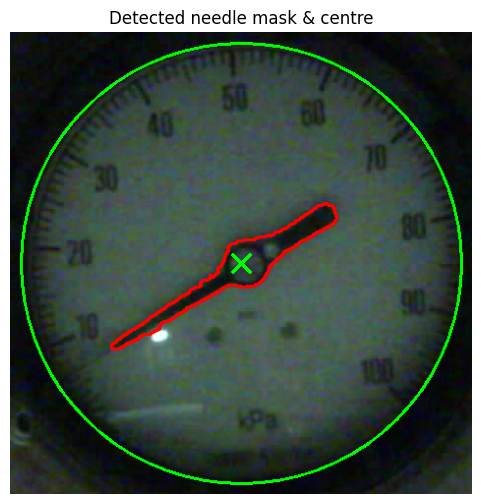

In [28]:
overlay = crop.copy()
cv2.circle(overlay, (int(cx_crop), int(cy_crop)), radius, (0,255,0), 2)
cv2.drawContours(overlay, [needle_cand], -1, (255,0,0), 2)
cv2.drawMarker(overlay, (int(cx_crop), int(cy_crop)), (0,255,0),
               markerType=cv2.MARKER_TILTED_CROSS, markerSize=18, thickness=2)
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis('off')
plt.title("Detected needle mask & centre")
plt.show()


## Get tip

In [29]:
# Flatten the contour points
pts = needle_cand.reshape(-1, 2)

# Distance from each contour point to the known centre
dists = np.hypot(pts[:,0] - cx_crop, pts[:,1] - cy_crop)

# Tip point = farthest contour point from centre
tip_idx = np.argmax(dists)
tip = pts[tip_idx]

tip

array([103, 322], dtype=int32)

Needle angle: 236.8°


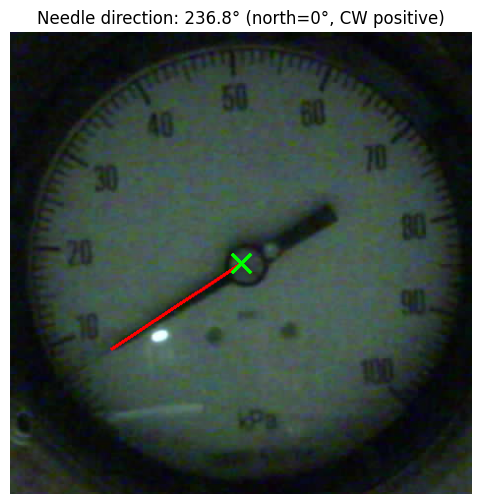

In [39]:
dx = tip[0] - cx_crop
dy = tip[1] - cy_crop

# Convert to degrees
angle_deg = (np.degrees(np.arctan2(dx, -dy)) + 360) % 360
print(f"Needle angle: {angle_deg:.1f}°")


overlay = crop.copy()
p1 = (int(cx_crop), int(cy_crop))
p2 = (int(tip[0]), int(tip[1]))

cv2.line(overlay, p1, p2, (255,0,0), 2)
cv2.drawMarker(overlay, p1, (0,255,0),
               markerType=cv2.MARKER_TILTED_CROSS, markerSize=18, thickness=2)
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis('off')
plt.title(f"Needle direction: {angle_deg:.1f}° (north=0°, CW positive)")
plt.show()


## Read Rekognition text results

In [44]:
import numpy as np
import json

# --- inputs you already have ---
with open('../rekog_output.json', 'r') as f:
    rekog = json.load(f)
# crop.shape -> (h, w, 3)
# (cx_crop, cy_crop) -> gauge centre in crop coords
# needle_angle_deg -> from earlier step (north=0°, CW positive)

conf_thresh = 90.0  # ignore low-confidence text (e.g. Rekog "100" here is ~36%)
valid_tokens = set(str(v) for v in range(0, 101, 10))  # {"0","10",...,"100"}

h, w = crop.shape[:2]

def bbox_center_px(bb):
    # Rekognition bbox is normalized
    cx = (bb["Left"] + bb["Width"]/2.0) * w
    cy = (bb["Top"]  + bb["Height"]/2.0) * h
    return cx, cy

def label_angle_deg(cx_lbl, cy_lbl):
    dx = cx_lbl - cx_crop
    dy = cy_lbl - cy_crop
    return (np.degrees(np.arctan2(dx, -dy)) + 360.0) % 360.0  # north=0°, CW+

# 1) collect label -> angle
vals, angs = [], []
for td in rekog["TextDetections"]:
    if td.get("Type") != "WORD":
        continue
    txt = td.get("DetectedText", "").strip()
    if txt not in valid_tokens:
        continue
    conf = float(td.get("Confidence", 0))
    if conf < conf_thresh:
        continue
    bb = td["Geometry"]["BoundingBox"]
    lx, ly = bbox_center_px(bb)
    ang = label_angle_deg(lx, ly)
    vals.append(int(txt))
    angs.append(ang)

assert len(vals) >= 3, f"Need at least 3 tick labels; got {len(vals)}."

# 2) sort by numeric value
vals = np.array(vals)
angs = np.array(angs)
order = np.argsort(vals)
vals = vals[order]
angs = angs[order]

# 3) unwrap angles to be monotonic with increasing values
#    (we allow adding 360° to later items to avoid wrap-around)
unwrap = angs.copy()
for i in range(1, len(unwrap)):
    while unwrap[i] < unwrap[i-1] - 180:
        unwrap[i] += 360
    while unwrap[i] > unwrap[i-1] + 180:
        unwrap[i] -= 360

# Now make fully increasing by lifting later angles if needed
for i in range(1, len(unwrap)):
    if unwrap[i] <= unwrap[i-1]:
        # push it just above previous (add k*360)
        k = int(np.floor((unwrap[i-1] - unwrap[i]) / 360.0)) + 1
        unwrap[i] += 360.0 * k

# 4) linear fit: reading ≈ a + b * angle_unwrapped
#    (independent var = angle, dependent = value)
A = np.vstack([np.ones_like(unwrap), unwrap]).T
coeff, _, _, _ = np.linalg.lstsq(A, vals.astype(float), rcond=None)
a, b = coeff  # reading = a + b * angle

# 5) map needle angle -> unwrap it near the calibration span
needle = float(angle_deg)

# choose the unwrap for the needle that keeps it close to the fitted span
span_lo, span_hi = unwrap.min(), unwrap.max()
# try needle shifted by k*360 for k in {-1,0,1,2} and pick closest to span
candidates = [needle + 360*k for k in (-1, 0, 1, 2)]
needle_unwrapped = min(candidates, key=lambda x: min(abs(x - span_lo), abs(x - span_hi)))

reading = a + b * needle_unwrapped

# clamp to labeled range (optionally extend a little if you want)
reading_clamped = float(np.clip(reading, vals.min(), vals.max()))

print(f"Labels used: {list(zip(vals.tolist(), np.round(unwrap,1).tolist()))}")
print(f"Fit: reading ≈ {a:.3f} + {b:.3f} * angle")
print(f"Needle angle: {angle_deg:.1f}°  ->  reading ≈ {reading:.2f}  (clamped: {reading_clamped:.2f})")


Labels used: [(10, 244.9), (20, 269.2), (30, 296.8), (40, 325.7), (50, 357.1), (60, 388.5), (70, 417.0), (80, 442.4), (90, 465.8)]
Fit: reading ≈ -75.154 + 0.351 * angle
Needle angle: 236.8°  ->  reading ≈ 8.02  (clamped: 10.00)
